In [62]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [63]:
import kagglehub

path = kagglehub.dataset_download("ashery/chexpert")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ashery/chexpert


In [64]:
path = kagglehub.dataset_download("ashery/chexpert")
print("Path to dataset files:", path)

csv_path = os.path.join(path, "train.csv")

df = pd.read_csv(csv_path)

df_subset = df.sample(n=4000, random_state=42).reset_index(drop=True)

print(f"data downloded {len(df_subset)}")

Path to dataset files: /kaggle/input/datasets/ashery/chexpert
data downloded 4000


In [65]:

train_df = pd.read_csv("/kaggle/input/datasets/ashery/chexpert/train.csv")
valid_df = pd.read_csv("/kaggle/input/datasets/ashery/chexpert/valid.csv")

In [66]:
train_df

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223409,CheXpert-v1.0-small/train/patient64537/study2/...,Male,59,Frontal,AP,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,-1.0,0.0,1.0,NaN,NaN,NaN
223410,CheXpert-v1.0-small/train/patient64537/study1/...,Male,59,Frontal,AP,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,0.0,-1.0,NaN,-1.0,NaN,NaN,NaN
223411,CheXpert-v1.0-small/train/patient64538/study1/...,Female,0,Frontal,AP,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223412,CheXpert-v1.0-small/train/patient64539/study1/...,Female,0,Frontal,AP,NaN,NaN,1.0,1.0,NaN,NaN,NaN,-1.0,1.0,0.0,NaN,NaN,NaN,0.0


In [67]:
train_df = train_df.head(4000)

In [68]:
train_df

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,CheXpert-v1.0-small/train/patient00980/study7/...,Male,59,Frontal,AP,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0,NaN,NaN,NaN
3996,CheXpert-v1.0-small/train/patient00980/study6/...,Male,58,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN
3997,CheXpert-v1.0-small/train/patient00980/study8/...,Male,59,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
3998,CheXpert-v1.0-small/train/patient00980/study5/...,Male,58,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,-1.0,0.0,1.0,NaN,NaN,NaN


In [69]:
train_df.isnull().sum()

Path                             0
Sex                              0
Age                              0
Frontal/Lateral                  0
AP/PA                          811
No Finding                    3527
Enlarged Cardiomediastinum    3133
Cardiomegaly                  3064
Lung Opacity                  2027
Lung Lesion                   3739
Edema                         2528
Consolidation                 2646
Pneumonia                     3543
Atelectasis                   2908
Pneumothorax                  2531
Pleural Effusion              1562
Pleural Other                 3854
Fracture                      3757
Support Devices               2001
dtype: int64

In [70]:
train_df = train_df.sample(n=4000, random_state=42).reset_index(drop=True).copy()

In [71]:
columns_to_drop = ['Age', 'Sex', 'Frontal/Lateral']

In [72]:
train_df.drop(columns=columns_to_drop, axis=1, inplace=True)

In [73]:
train_df_filled = train_df.fillna(0)

In [74]:
train_df_filled.isnull().sum()

Path                          0
AP/PA                         0
No Finding                    0
Enlarged Cardiomediastinum    0
Cardiomegaly                  0
Lung Opacity                  0
Lung Lesion                   0
Edema                         0
Consolidation                 0
Pneumonia                     0
Atelectasis                   0
Pneumothorax                  0
Pleural Effusion              0
Pleural Other                 0
Fracture                      0
Support Devices               0
dtype: int64

In [75]:
import os
print(os.listdir("/kaggle/input/datasets/ashery/chexpert/"))

['valid.csv', 'valid', 'train.csv', 'train']


In [76]:
train_df['Path'] = '/kaggle/input/datasets/ashery/chexpert/' + train_df['Path']

In [77]:
import os

def perfect_path_fix(old_path, base_path):
    old_path = str(old_path)
    if 'train/' in old_path:
        relative_part = old_path.split('train/')[-1]
        return os.path.join(base_path, 'train', relative_part)
    elif 'valid/' in old_path:
        relative_part = old_path.split('valid/')[-1]
        return os.path.join(base_path, 'valid', relative_part)
    return old_path

train_df['Path'] = train_df['Path'].apply(lambda x: perfect_path_fix(x, path))

print("new path:")
print(train_df["Path"].iloc[0])
print("\n new image :", os.path.exists(train_df["Path"].iloc[0]))

new path:
/kaggle/input/datasets/ashery/chexpert/train/patient00140/study6/view1_frontal.jpg

 new image : True


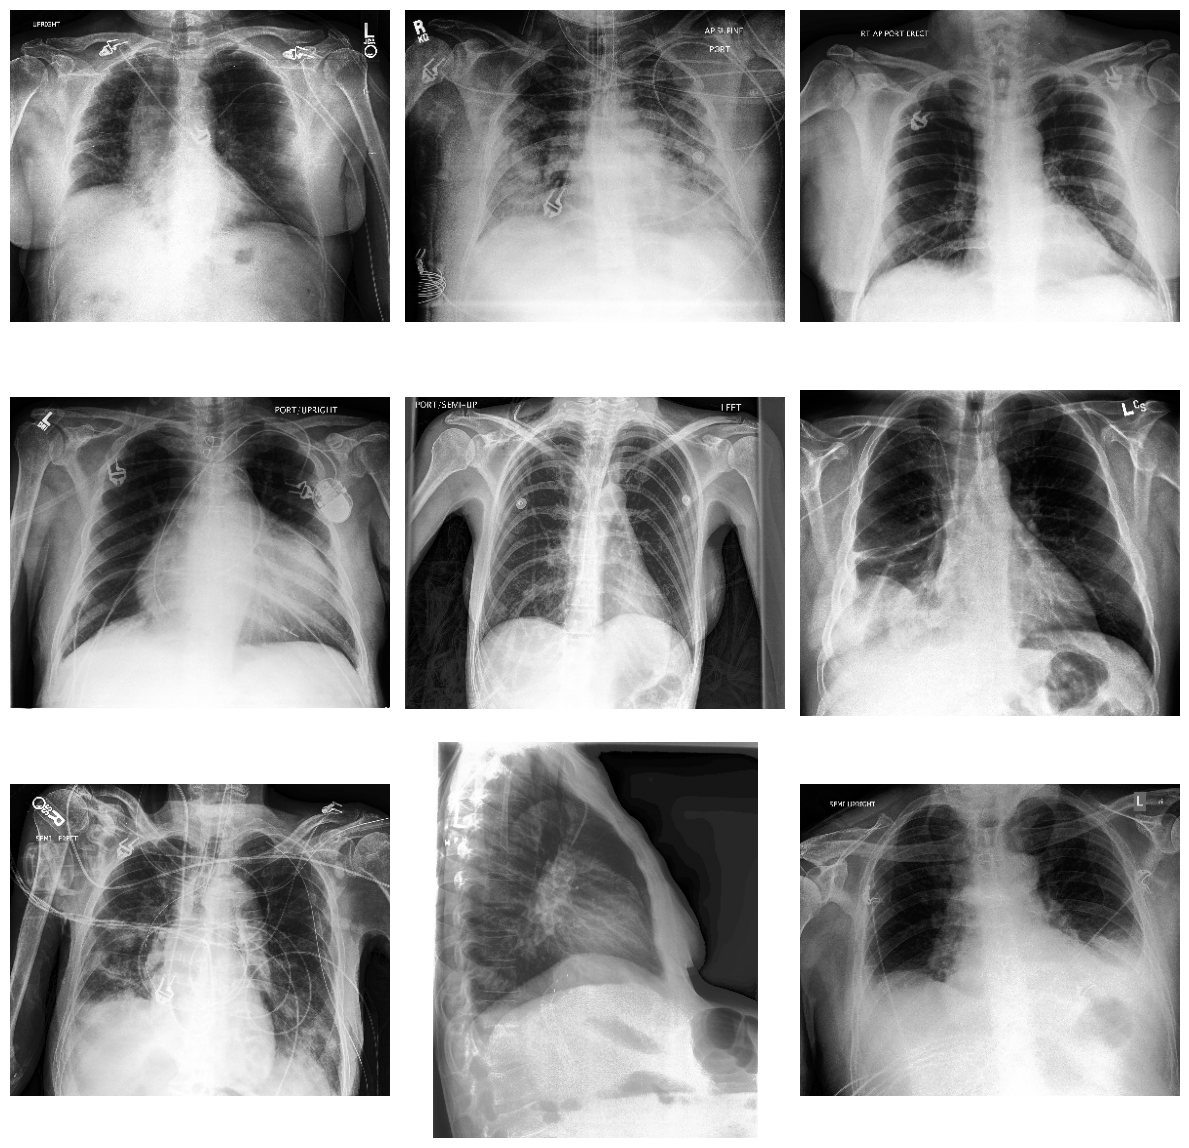

In [78]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(12, 12))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    img = Image.open(train_df["Path"].iloc[i])

    plt.imshow(img, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [79]:
valid_df.drop(columns=columns_to_drop, axis=1, inplace=True)

In [80]:
valid_df.isnull().sum()

Path                           0
AP/PA                         32
No Finding                     0
Enlarged Cardiomediastinum     0
Cardiomegaly                   0
Lung Opacity                   0
Lung Lesion                    0
Edema                          0
Consolidation                  0
Pneumonia                      0
Atelectasis                    0
Pneumothorax                   0
Pleural Effusion               0
Pleural Other                  0
Fracture                       0
Support Devices                0
dtype: int64

In [81]:
valid_df_filled = train_df.fillna(0)

In [82]:
valid_df_filled.isnull().sum()

Path                          0
AP/PA                         0
No Finding                    0
Enlarged Cardiomediastinum    0
Cardiomegaly                  0
Lung Opacity                  0
Lung Lesion                   0
Edema                         0
Consolidation                 0
Pneumonia                     0
Atelectasis                   0
Pneumothorax                  0
Pleural Effusion              0
Pleural Other                 0
Fracture                      0
Support Devices               0
dtype: int64

In [83]:
train_df_filled[col] = train_df_filled[col].apply(lambda x: 1.0 if x == 1.0 else 0.0)

In [84]:
def clean_labels(label_list):
    return [1.0 if val == 1.0 else 0.0 for val in label_list]

train_data['labels'] = train_data['labels'].apply(clean_labels)
valid_data['labels'] = valid_data['labels'].apply(clean_labels)

In [85]:
import pandas as pd

target_columns = [col for col in train_df_filled.columns if col != 'Path']

filepaths = train_df_filled['Path'].tolist()

labels = train_df_filled[target_columns].values.tolist()

train_df = pd.DataFrame({
    'filepaths': filepaths,
    'labels': labels
})

train_df.head()

,filepaths,labels
0,CheXpert-v1.0-small/train/patient00140/study6/...,"[AP, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 0.0, ..."
1,CheXpert-v1.0-small/train/patient00848/study5/...,"[AP, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0..."
2,CheXpert-v1.0-small/train/patient00138/study2/...,"[AP, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0..."
3,CheXpert-v1.0-small/train/patient00965/study4/...,"[AP, 0.0, 0.0, 1.0, 0.0, 0.0, -1.0, 0.0, 0.0, ..."
4,CheXpert-v1.0-small/train/patient00726/study1/...,"[AP, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0..."


In [86]:
import pandas as pd
import numpy as np

target_columns = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices'
]

target_columns = [col for col in target_columns if col in train_df_filled.columns]

for col in target_columns:
    train_df_filled[col] = train_df_filled[col].apply(lambda x: 1.0 if x == 1.0 else 0.0)
    
filepaths = train_df_filled['Path'].tolist()
labels = train_df_filled[target_columns].values.tolist()

train_df = pd.DataFrame({
    'filepaths': filepaths,
    'labels': labels
})
from sklearn.model_selection import train_test_split
train_data, valid_data = train_test_split(train_df, test_size=0.2, random_state=42)

print("done")

done


In [87]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

def load_and_preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, tf.cast(label, tf.float32)

def absolute_path_fix_v2(p):
    p = str(p)
    base_kaggle_path = '/kaggle/input'
    if 'train/' in p:
        relative_part = p.split('train/')[-1]
        for root, dirs, files in os.walk(base_kaggle_path):
            if 'train' in dirs: return os.path.join(root, 'train', relative_part)
        return os.path.join(base_kaggle_path, 'train', relative_part)
    elif 'valid/' in p:
        relative_part = p.split('valid/')[-1]
        for root, dirs, files in os.walk(base_kaggle_path):
            if 'valid' in dirs: return os.path.join(root, 'valid', relative_part)
        return os.path.join(base_kaggle_path, 'valid', relative_part)
    return p

X_paths = [absolute_path_fix_v2(p) for p in train_data['filepaths'].values]
X_val_paths = [absolute_path_fix_v2(p) for p in valid_data['filepaths'].values]

Y_labels = np.array(train_data['labels'].tolist(), dtype=np.float32)
Y_val_labels = np.array(valid_data['labels'].tolist(), dtype=np.float32)

train_dataset = tf.data.Dataset.from_tensor_slices((X_paths, Y_labels))
train_dataset = train_dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=500).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_tensor_slices((X_val_paths, Y_val_labels))
valid_dataset = valid_dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
valid_dataset = valid_dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

print('done')

done


In [88]:
import tensorflow as tf
import numpy as np
import os

IMG_SIZE = 224
BATCH_SIZE = 32

def load_and_preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, tf.cast(label, tf.float32)

def absolute_path_fix(p, base_path):
    p = str(p)
    if not p.startswith(base_path):
        if 'train/' in p:
            return os.path.join(base_path, 'train', p.split('train/')[-1])
        elif 'valid/' in p:
            return os.path.join(base_path, 'valid', p.split('valid/')[-1])
    return p

X_paths = [absolute_path_fix(p, path) for p in train_data['filepaths'].values]
X_val_paths = [absolute_path_fix(p, path) for p in valid_data['filepaths'].values]

Y_labels = np.array(train_data['labels'].tolist(), dtype=np.float32)
Y_val_labels = np.array(valid_data['labels'].tolist(), dtype=np.float32)

print("true path:")
print(X_paths[0])
print("new image :", os.path.exists(X_paths[0]))

train_dataset = tf.data.Dataset.from_tensor_slices((X_paths, Y_labels))
train_dataset = train_dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=500).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_tensor_slices((X_val_paths, Y_val_labels))
valid_dataset = valid_dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
valid_dataset = valid_dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

print("\n Data Loader done")

true path:
/kaggle/input/datasets/ashery/chexpert/train/patient00261/study2/view1_frontal.jpg
new image : True

 Data Loader done


In [89]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.config.optimizer.set_experimental_options({"layout_optimizer": False})

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"), 
    layers.RandomRotation(0.1), 
    layers.RandomContrast(0.15)
])

num_classes = Y_labels.shape[1]

base_model = tf.keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False 

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs) 
x = base_model(x, training=False) 
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x) 
x = layers.Dropout(0.5)(x) 
outputs = layers.Dense(num_classes, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc'), 'binary_accuracy']
)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
]

history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=30,
    callbacks=callbacks
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 174ms/step - auc: 0.5376 - binary_accuracy: 0.6390 - loss: 0.7315 - val_auc: 0.5892 - val_binary_accuracy: 0.8556 - val_loss: 0.3721 - learning_rate: 0.0010
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - auc: 0.5685 - binary_accuracy: 0.8220 - loss: 0.4322 - val_auc: 0.6221 - val_binary_accuracy: 0.8608 - val_loss: 0.3464 - learning_rate: 0.0010
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - auc: 0.6033 - binary_accuracy: 0.8432 - loss: 0.3890 - val_auc: 0.6380 - val_binary_accuracy: 0.8604 - val_loss: 0.3479 - learning_rate: 0.0010
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - auc: 0.6206 - binary_accuracy: 0.8525 - loss: 0.3678
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - auc: 0.6216 - binary_accuracy: 0.8489 - loss: 0.3739 - val_auc: 0.6393 - val_binary_accuracy: 0.8619 - val_loss: 0.3487

In [91]:
model.save_weights('feature.weights.h5')

In [90]:

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc'), 'binary_accuracy']
)

fine_tune_callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

history_fine = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=30,
    callbacks=fine_tune_callbacks
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - auc: 0.6521 - binary_accuracy: 0.8552 - loss: 0.3437 - val_auc: 0.6629 - val_binary_accuracy: 0.8638 - val_loss: 0.3397 - learning_rate: 1.0000e-05
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - auc: 0.6534 - binary_accuracy: 0.8583 - loss: 0.3412 - val_auc: 0.6612 - val_binary_accuracy: 0.8616 - val_loss: 0.3424 - learning_rate: 1.0000e-05
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - auc: 0.6478 - binary_accuracy: 0.8588 - loss: 0.3416 - val_auc: 0.6554 - val_binary_accuracy: 0.8608 - val_loss: 0.3419 - learning_rate: 1.0000e-05
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - auc: 0.6653 - binary_accuracy: 0.8576 - loss: 0.3388 - val_auc: 0.6543 - val_binary_accuracy: 0.8612 - val_loss: 0.3415 - learning_rate: 1.0000e-05
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - auc: 0.6617 - binary_accuracy: 0.8591 - loss: 0.3381 - val_auc: 0.6589 - val_binary_accuracy: 0.8620 - val_loss: 0.3405 - l

In [93]:
model.save_weights('fine_tuning.weights.h5')